# Principal Component Analysis (PCA) — Full Working Notebook

This notebook is a complete, hands-on walkthrough of PCA, built so nothing has to be
taken on faith — every claim is backed by runnable code on real datasets.

**What this notebook covers (in order):**
1. Load a real dataset (Breast Cancer — classification-flavoured feature set)
2. Why we must **standardize** features before PCA (with a "without-scaling vs
   with-scaling" demo that shows misleading components when we skip scaling)
3. Covariance matrix + eigenvalues/eigenvectors **by hand** (`np.linalg.eig`) on a
   tiny toy dataset, cross-checked against `sklearn.decomposition.PCA`
4. `explained_variance_ratio_`, cumulative variance, scree plot, and choosing
   the number of components (≥95% rule)
5. 2D and 3D visualization of PCA-transformed data, colored by class label
6. Downstream **classification** demo: Logistic Regression on PCA-reduced features
7. Downstream **regression** demo: Linear Regression on PCA-reduced features
   (different dataset, since PCA is task-agnostic — it feeds both pipelines)

PCA itself is **unsupervised** — it has no separate "classification version" or
"regression version". It is a *preprocessing / dimensionality-reduction* step;
sections 6 and 7 below show it plugged into both kinds of downstream supervised
models to make that point concrete rather than just stating it.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

np.set_printoptions(suppress=True, precision=4)

## 1. Load the dataset

We use `load_breast_cancer` — 30 numeric features describing cell nuclei, and a
binary target (malignant / benign). It is a good PCA demo dataset because the
30 features are highly correlated with each other (redundant information) and
are measured on **very different scales** (e.g. `mean area` is in the hundreds,
`mean smoothness` is around 0.05–0.2) — exactly the situation PCA is meant for,
and exactly the situation that breaks PCA if you forget to scale.

In [2]:
df = load_breast_cancer(as_frame=True).frame
df.shape

(569, 31)

In [3]:
X = df.drop('target', axis=1)
y = df['target']
X.describe().loc[['mean', 'std']].T.head(8)  # notice wildly different scales

,mean,std
mean radius,14.127292,3.524049
mean texture,19.289649,4.301036
mean perimeter,91.969033,24.298981
mean area,654.889104,351.914129
mean smoothness,0.096360,0.014064
mean compactness,0.104341,0.052813
mean concavity,0.088799,0.079720
mean concave points,0.048919,0.038803


## 2. Why scaling matters before PCA

PCA finds the directions of **maximum variance**. Variance is scale-dependent:
a feature measured in the hundreds (e.g. `mean area`) will have a numerically
huge variance compared to a feature measured in fractions (e.g.
`mean smoothness`), even if the *smoothness* feature is just as informative
(or more informative) about the target.

If we run PCA on the raw, unscaled data, the first principal component will be
hijacked by whichever feature happens to have the largest numeric scale — not
whichever feature actually varies most *meaningfully*. This is a classic PCA
pitfall. Bengali intuition: **স্কেল না ঠিক করলে PCA বড় সংখ্যার feature-কেই
সবচেয়ে "গুরুত্বপূর্ণ" ভেবে ভুল করবে** — even though that's just a unit-of-measurement
accident, not real importance.

Below: PCA fit on raw `X` (no scaling) vs PCA fit on `StandardScaler`-transformed
`X`. Look at (a) how concentrated the "explained variance" is in PC1 without
scaling, and (b) which original features dominate PC1 in each case.

In [4]:
# ---- WITHOUT scaling ----
pca_unscaled = PCA(n_components=5)
pca_unscaled.fit(X)

print("Explained variance ratio (UNSCALED):", pca_unscaled.explained_variance_ratio_)

# Which raw features dominate PC1? (largest |loading|)
loadings_unscaled = pd.Series(pca_unscaled.components_[0], index=X.columns)
print("\nTop 5 |loading| contributors to PC1 (UNSCALED):")
print(loadings_unscaled.abs().sort_values(ascending=False).head(5))

Explained variance ratio (UNSCALED): [0.982  0.0162 0.0016 0.0001 0.0001]

Top 5 |loading| contributors to PC1 (UNSCALED):
worst area         0.852063
mean area          0.516826
area error         0.055727
worst perimeter    0.049458
mean perimeter     0.035076
dtype: float64


In [5]:
# ---- WITH scaling ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=5)
pca_scaled.fit(X_scaled)

print("Explained variance ratio (SCALED):", pca_scaled.explained_variance_ratio_)

loadings_scaled = pd.Series(pca_scaled.components_[0], index=X.columns)
print("\nTop 5 |loading| contributors to PC1 (SCALED):")
print(loadings_scaled.abs().sort_values(ascending=False).head(5))

Explained variance ratio (SCALED): [0.4427 0.1897 0.0939 0.066  0.055 ]

Top 5 |loading| contributors to PC1 (SCALED):
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
dtype: float64


**What to notice:** without scaling, PC1 usually explains an unrealistically
huge share of variance (often >98%) and is dominated by the raw large-magnitude
features (e.g. `mean area`, `worst area` — anything measured in absolute
squared-pixel/mm units). After scaling, the explained variance is more evenly
spread across the first few components, and PC1's loadings are a genuine mix of
many features — this is the trustworthy version. **Rule: always
`StandardScaler` (or similar) before PCA unless all your features are already
on the same, meaningful scale.**

## 3. Covariance matrix & eigen-decomposition — by hand

Before trusting `sklearn.decomposition.PCA` as a black box, let's do PCA
manually on a tiny 2D toy dataset (10 points) — the same textbook example used
in the README's worked math example — so every number can be traced.

Steps performed manually:
1. Mean-center the data.
2. Compute the covariance matrix two ways: `(1/(n-1)) · XᵀX` (manual formula)
   and `np.cov` (library), and confirm they match.
3. Get eigenvalues/eigenvectors of the covariance matrix with `np.linalg.eig`.
4. Sort eigenvectors by descending eigenvalue → these are the principal
   components, ranked by how much variance they capture.
5. Project the centered data onto the eigenvectors to get the PCA scores.
6. Cross-check every number against `sklearn.decomposition.PCA` fit on the same
   data.

In [6]:
X_toy = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9],
])

n = X_toy.shape[0]
mean_toy = X_toy.mean(axis=0)
Xc = X_toy - mean_toy

print("Mean:", mean_toy)
print("\nMean-centered data:\n", Xc)

Mean: [1.81 1.91]

Mean-centered data:
 [[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]


In [7]:
# Step 2: covariance matrix — manual formula vs np.cov
cov_manual = (Xc.T @ Xc) / (n - 1)
cov_lib = np.cov(X_toy, rowvar=False)

print("Covariance (manual (1/(n-1)) XcᵀXc):\n", cov_manual)
print("\nCovariance (np.cov):\n", cov_lib)
print("\nMatch:", np.allclose(cov_manual, cov_lib))

Covariance (manual (1/(n-1)) XcᵀXc):
 [[0.6166 0.6154]
 [0.6154 0.7166]]

Covariance (np.cov):
 [[0.6166 0.6154]
 [0.6154 0.7166]]

Match: True


In [8]:
# Step 3-4: eigenvalues / eigenvectors of the covariance matrix, sorted
eigvals, eigvecs = np.linalg.eig(cov_manual)

order = np.argsort(eigvals)[::-1]          # descending order
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]          # each COLUMN is an eigenvector

print("Eigenvalues (sorted desc):", eigvals_sorted)
print("\nEigenvectors (as columns, sorted to match):\n", eigvecs_sorted)

explained_ratio_manual = eigvals_sorted / eigvals_sorted.sum()
print("\nExplained variance ratio (manual):", explained_ratio_manual)

Eigenvalues (sorted desc): [1.284  0.0491]

Eigenvectors (as columns, sorted to match):
 [[-0.6779 -0.7352]
 [-0.7352  0.6779]]

Explained variance ratio (manual): [0.9632 0.0368]


In [9]:
# Step 5: project centered data onto the eigenvectors -> PCA scores
scores_manual = Xc @ eigvecs_sorted
print("Manual PCA scores (first column = PC1):\n", scores_manual)

Manual PCA scores (first column = PC1):
 [[-0.828  -0.1751]
 [ 1.7776  0.1429]
 [-0.9922  0.3844]
 [-0.2742  0.1304]
 [-1.6758 -0.2095]
 [-0.9129  0.1753]
 [ 0.0991 -0.3498]
 [ 1.1446  0.0464]
 [ 0.438   0.0178]
 [ 1.2238 -0.1627]]


In [10]:
# Step 6: cross-check against sklearn
pca_toy = PCA(n_components=2)
scores_sklearn = pca_toy.fit_transform(X_toy)

print("sklearn explained_variance_:", pca_toy.explained_variance_)
print("sklearn explained_variance_ratio_:", pca_toy.explained_variance_ratio_)
print("sklearn components_ (each ROW is a component):\n", pca_toy.components_)
print("\nsklearn scores:\n", scores_sklearn)

# Note: eigenvector sign is arbitrary (v and -v are both valid eigenvectors),
# so sklearn's sign may be flipped relative to our manual np.linalg.eig result.
# Magnitudes (|scores|, eigenvalues, explained_variance_ratio_) always match.
print("\n|manual scores| == |sklearn scores| ?",
      np.allclose(np.abs(scores_manual), np.abs(scores_sklearn), atol=1e-8))

sklearn explained_variance_: [1.284  0.0491]
sklearn explained_variance_ratio_: [0.9632 0.0368]
sklearn components_ (each ROW is a component):
 [[ 0.6779  0.7352]
 [ 0.7352 -0.6779]]

sklearn scores:
 [[ 0.828   0.1751]
 [-1.7776 -0.1429]
 [ 0.9922 -0.3844]
 [ 0.2742 -0.1304]
 [ 1.6758  0.2095]
 [ 0.9129 -0.1753]
 [-0.0991  0.3498]
 [-1.1446 -0.0464]
 [-0.438  -0.0178]
 [-1.2238  0.1627]]

|manual scores| == |sklearn scores| ? True


## 4. Full PCA on the (scaled) Breast Cancer data — explained variance & scree plot

Now back to the real 30-feature dataset. Fit PCA with all components on the
**scaled** data, inspect `explained_variance_ratio_`, its cumulative sum, and
plot the scree plot (both individual bars and the cumulative line).

In [11]:
pca_full = PCA(n_components=None)
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_variance = np.cumsum(explained)

print("Explained variance ratio (first 10):", explained[:10])
print("\nCumulative variance (first 10):", cum_variance[:10])

Explained variance ratio (first 10): [0.4427 0.1897 0.0939 0.066  0.055  0.0402 0.0225 0.0159 0.0139 0.0117]

Cumulative variance (first 10): [0.4427 0.6324 0.7264 0.7924 0.8473 0.8876 0.9101 0.926  0.9399 0.9516]


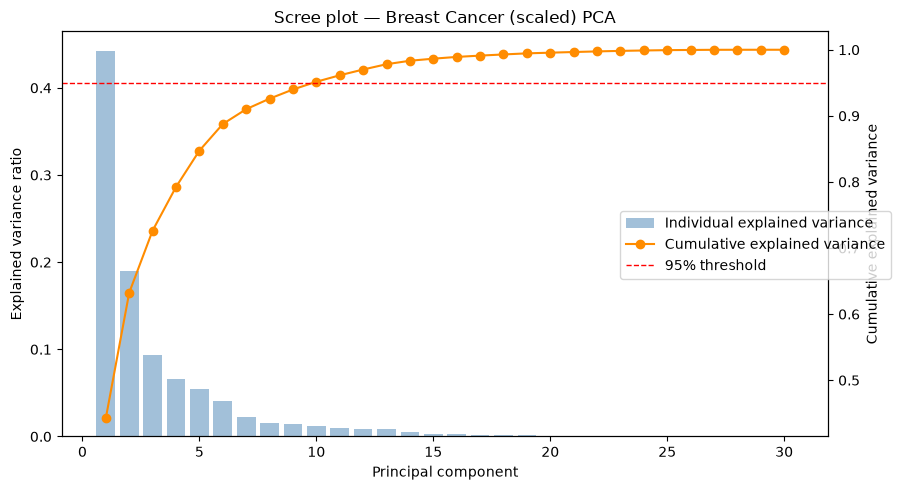

In [12]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(range(1, len(explained) + 1), explained, alpha=0.5,
        label="Individual explained variance", color="steelblue")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o',
         color="darkorange", label="Cumulative explained variance")
ax2.axhline(0.95, color='red', linestyle='--', linewidth=1, label="95% threshold")
ax2.set_ylabel("Cumulative explained variance")

fig.legend(loc="center right")
plt.title("Scree plot — Breast Cancer (scaled) PCA")
plt.tight_layout()
plt.show()

## 5. Choosing the number of components (≥95% variance rule)

A common rule of thumb: keep the smallest number of components whose
cumulative explained variance crosses a threshold (commonly 90–95%).

In [13]:
n_components_95 = int(np.argmax(cum_variance >= 0.95) + 1)
print(f"Components needed to reach >= 95% variance: {n_components_95}")
print(f"Cumulative variance at that count: {cum_variance[n_components_95 - 1]:.4f}")

# sklearn can do this selection automatically by passing a float in (0, 1)
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(f"\nsklearn PCA(n_components=0.95) picked {pca_95.n_components_} components "
      f"(matches manual choice: {pca_95.n_components_ == n_components_95})")

Components needed to reach >= 95% variance: 10
Cumulative variance at that count: 0.9516

sklearn PCA(n_components=0.95) picked 10 components (matches manual choice: True)


## 6. Visualizing PCA-transformed data (2D and 3D), colored by class

Even though 30 dimensions can't be visualized, the first 2–3 principal
components usually capture most of the *separability* structure — plotting
them colored by the true class label is a quick sanity check on whether PCA is
preserving information relevant to classification (it doesn't know about the
labels at all — it only sees variance).

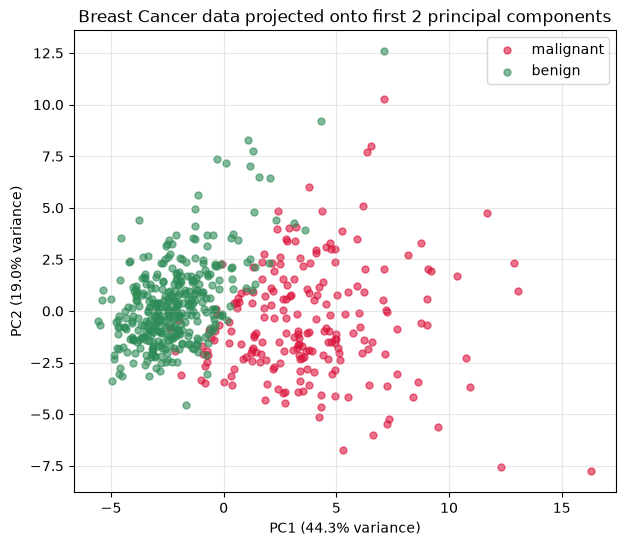

In [14]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
for label, name, color in [(0, "malignant", "crimson"), (1, "benign", "seagreen")]:
    mask = (y == label)
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, alpha=0.6, s=25, color=color)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Breast Cancer data projected onto first 2 principal components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

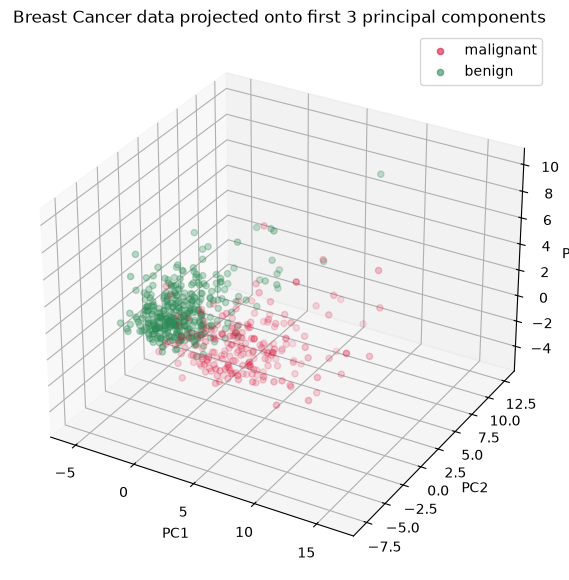

In [15]:
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

for label, name, color in [(0, "malignant", "crimson"), (1, "benign", "seagreen")]:
    mask = (y == label)
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               label=name, alpha=0.6, s=20, color=color)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Breast Cancer data projected onto first 3 principal components")
ax.legend()
plt.show()

Both plots show benign vs malignant points forming largely separable clusters even after collapsing 30 features down to 2-3 — evidence that the *high-variance* directions PCA found also happen to carry a lot of the *class-relevant* signal here (this is not guaranteed in general — see Disadvantages in the README).

## 7. Downstream demo (a): Classification on PCA-reduced features

PCA doesn't know or care what the downstream task is. Here we plug it in
front of a `LogisticRegression` classifier and compare accuracy with vs
without PCA.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Pipeline WITHOUT PCA: Scale -> Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_no_pca.fit(X_train, y_train)
pred_no_pca = pipe_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, pred_no_pca)
print("Accuracy (No PCA):", acc_no_pca)

Accuracy (No PCA): 0.9824561403508771


In [17]:
# Pipeline WITH PCA: Scale -> PCA(10 components) -> Logistic Regression
pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_with_pca.fit(X_train, y_train)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_with_pca = accuracy_score(y_test, pred_with_pca)
print("Accuracy (With PCA, 10 components):", acc_with_pca)
print(f"\nOriginal feature count: {X_train.shape[1]}  ->  PCA feature count: 10")

Accuracy (With PCA, 10 components): 0.9736842105263158

Original feature count: 30  ->  PCA feature count: 10


### Explanation of the classification results

If PCA accuracy is similar:
- Great — we reduced dimensions (30 → 10) without losing performance.

If PCA accuracy is better:
- PCA likely removed redundancy/noise that was confusing the model.

If PCA accuracy is worse:
- We removed useful information.
- Increase the variance threshold (e.g., 0.98), or skip PCA for this problem.

Bottom line: PCA is a tool, not a rule. Use it when it matches the problem's
conditions (many correlated features, need for speed/visualization/denoising).

## 8. Downstream demo (b): Regression on PCA-reduced features

To make it unmistakably clear that PCA is **agnostic to the downstream
supervised task**, we repeat the same idea on a *regression* problem —
`load_diabetes` (predicting a continuous disease-progression score from 10
numeric features) — with `LinearRegression` instead of `LogisticRegression`.

In [18]:
diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data
y_reg = diabetes.target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Pipeline WITHOUT PCA: Scale -> Linear Regression
reg_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg_no_pca.fit(Xr_train, yr_train)
pred_reg_no_pca = reg_no_pca.predict(Xr_test)

r2_no_pca = r2_score(yr_test, pred_reg_no_pca)
mse_no_pca = mean_squared_error(yr_test, pred_reg_no_pca)
print(f"No PCA   -> R^2: {r2_no_pca:.4f}, MSE: {mse_no_pca:.2f}, features used: {X_reg.shape[1]}")

No PCA   -> R^2: 0.4526, MSE: 2900.19, features used: 10


In [19]:
# Pipeline WITH PCA: Scale -> PCA(95% variance) -> Linear Regression
reg_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("reg", LinearRegression())
])
reg_with_pca.fit(Xr_train, yr_train)
pred_reg_with_pca = reg_with_pca.predict(Xr_test)

r2_with_pca = r2_score(yr_test, pred_reg_with_pca)
mse_with_pca = mean_squared_error(yr_test, pred_reg_with_pca)
n_comp_used = reg_with_pca.named_steps["pca"].n_components_

print(f"With PCA -> R^2: {r2_with_pca:.4f}, MSE: {mse_with_pca:.2f}, "
      f"features used: {n_comp_used} (>= 95% variance)")

With PCA -> R^2: 0.4558, MSE: 2883.43, features used: 8 (>= 95% variance)


**Takeaway:** the exact same `PCA` class, with the exact same API
(`fit_transform` / `transform`), sits in front of a classifier in section 7 and
a regressor in section 8. PCA never looks at `y` — it only transforms `X`.
Whether the label downstream is discrete (classification) or continuous
(regression) is completely irrelevant to PCA itself; that's what "unsupervised
preprocessing / dimensionality reduction" means in practice, not just in
theory.

## 9. Overall summary of this notebook

- **Scaling matters**: unscaled PCA on this dataset is hijacked by
  large-magnitude features (e.g. `area`-based features); scaling fixes this.
- **Manual eigen-decomposition** on a 10-point toy dataset matches
  `sklearn.decomposition.PCA` exactly (up to eigenvector sign).
- **Scree plot + 95% rule** gave a concrete, defensible way to pick
  `n_components` instead of guessing.
- **2D/3D visualization** showed PCA compresses 30 dimensions into 2-3 while
  keeping benign/malignant clusters largely separable.
- **PCA feeds both classification (Logistic Regression) and regression
  (Linear Regression) pipelines** — same `PCA` object, same API, two
  completely different downstream tasks and datasets.

See `README.md` in this folder for the full theory (formulas, worked example,
advantages/disadvantages, comparisons to LDA/t-SNE/feature selection, common
pitfalls) that this notebook is the executable companion to.